# COMP 6940: Big Data and Data Visualization

### Project  

#### Airline Delay Analysis and Performance Optimization  
#### Dataset: Carrier On-Time Performance Dataset  

## **Notebook:** 02 — Exploratory Data Analysis  

**Objective:** 

This notebook explores the cleaned flight dataset to identify patterns, trends, and relationships in airline delays. The analysis focuses on temporal patterns, airline and airport performance, and the underlying factors contributing to arrival delays. The insights derived from this stage will guide further analysis and support data-driven conclusions regarding the delay behaviour.

---


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

In [32]:
df = pd.read_csv("cleaned_flight_data.csv", low_memory=False)
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

if "IsArrivalDelayed" not in df.columns:
    df["IsArrivalDelayed"] = df["ArrDelay"] > 0

oper = df[df["Cancelled"] == 0].copy()
oper["ArrDelay"] = pd.to_numeric(oper["ArrDelay"], errors="coerce")
oper["DepDelay"] = pd.to_numeric(oper["DepDelay"], errors="coerce")

### Analysis Dataset Validation

Before conducting exploratory analysis, the cleaned dataset is checked to confirm that the expected delay, date, and cancellation fields are present and usable. This ensures that the analysis is based only on completed flights with valid delay values.

In [33]:
required_cols = [
    "FlightDate",
    "Cancelled",
    "ArrDelay",
    "DepDelay",
    "IsArrivalDelayed",
    "Month",
    "DayOfWeek",
    "DepHour",
]

missing_required = [col for col in required_cols if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Dataset loaded successfully.")
print("Rows in full cleaned dataset:", len(df))
print("Rows in completed-flight analysis subset:", len(oper))
print("Remaining missing ArrDelay values in completed flights:", oper["ArrDelay"].isna().sum())
print("Remaining missing DepDelay values in completed flights:", oper["DepDelay"].isna().sum())

Dataset loaded successfully.
Rows in full cleaned dataset: 2000000
Rows in completed-flight analysis subset: 1963538
Remaining missing ArrDelay values in completed flights: 4616
Remaining missing DepDelay values in completed flights: 60


## 1. Dataset Size and Scope

Before conducting further analysis, it is important to understand the scale of the dataset. Given the large volume of flight records, even small percentages of delays can correspond to a significant number of affected flights.

This highlights the importance of analyzing both the proportion and absolute count of delays, as large-scale datasets amplify the real-world impact of operational inefficiencies.

In [34]:
n = len(df)
n_op = len(oper)
d0, d1 = df["FlightDate"].min(), df["FlightDate"].max()
print(f"Rows: {n:,}")
print(f"Non-cancelled rows: {n_op:,} ({100 * n_op / n:.1f}%)")
print(f"FlightDate range: {d0.date()} — {d1.date()}")

Rows: 2,000,000
Non-cancelled rows: 1,963,538 (98.2%)
FlightDate range: 1987-10-01 — 2020-03-31


### Delay Summary Statistics

Summary statistics are used to describe the distribution of arrival and departure delays. Delay data are typically skewed, with most flights having small delays and a small number experiencing very large delays.

In [35]:
delay_summary = oper[["ArrDelay", "DepDelay"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
).T

display(delay_summary)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
ArrDelay,1958922.0,6.205467,34.833399,-706.0,-10.0,-1.0,10.0,33.0,60.0,148.0,1898.0
DepDelay,1963478.0,8.575794,32.668097,-990.0,-3.0,0.0,7.0,29.0,57.0,144.0,1878.0


**Insight:** 

The analysis subset keeps only completed flights so arrival and departure delay minutes are defined; cancelled rows are retained in the file for completeness but excluded from delay-only charts.

---

## 2. How Common are Delays?

### Arrival Delay Prevalence

This section examines the proportion of flights that arrive on time or early compared to those that experience arrival delays. Establishing this baseline provides an initial understanding of how common delays are within airline operations.

Share of flights with ArrDelay > 0: 43.8%


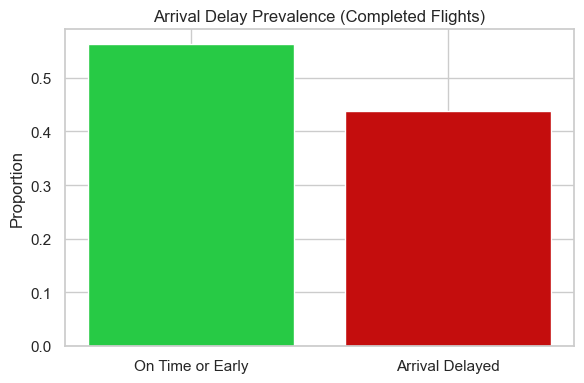

In [36]:
rate = oper["IsArrivalDelayed"].mean()
print(f"Share of flights with ArrDelay > 0: {100 * rate:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["On Time or Early", "Arrival Delayed"], [1 - rate, rate], color=["#27ca45", "#C40D0D"])
ax.set_ylabel("Proportion")
ax.set_title("Arrival Delay Prevalence (Completed Flights)")
plt.tight_layout()
plt.show()

**Insight:**

The results show that although a slightly larger proportion of flights arrive on time or early, a substantial percentage of flights still experience delays. This indicates that delays are not isolated events but occur regularly within the system.

Given the size of the dataset, even this proportion represents a large number of affected flights. This highlights the importance of identifying the key drivers of delays, as small improvements could have significant real-world impact.

---

## 3. When do delays occur?

### 3.1 Monthly Trends in Arrival Delays

**Monthly Average Arrival Delay and Delay Volume**

This section explores temporal patterns in arrival delays by analyzing both the average delay duration per month and the total number of delayed flights. Together, these two perspectives provide a more comprehensive understanding of delay behavior.

The average delay reflects the severity of delays when they occur.
The count of delayed flights reflects the frequency or volume of disruptions.

By examining these metrics jointly, we can distinguish between periods with frequent minor delays and periods characterized by fewer but more severe disruptions. This dual analysis is essential for identifying seasonal patterns, operational bottlenecks, and potential capacity constraints within the aviation system.

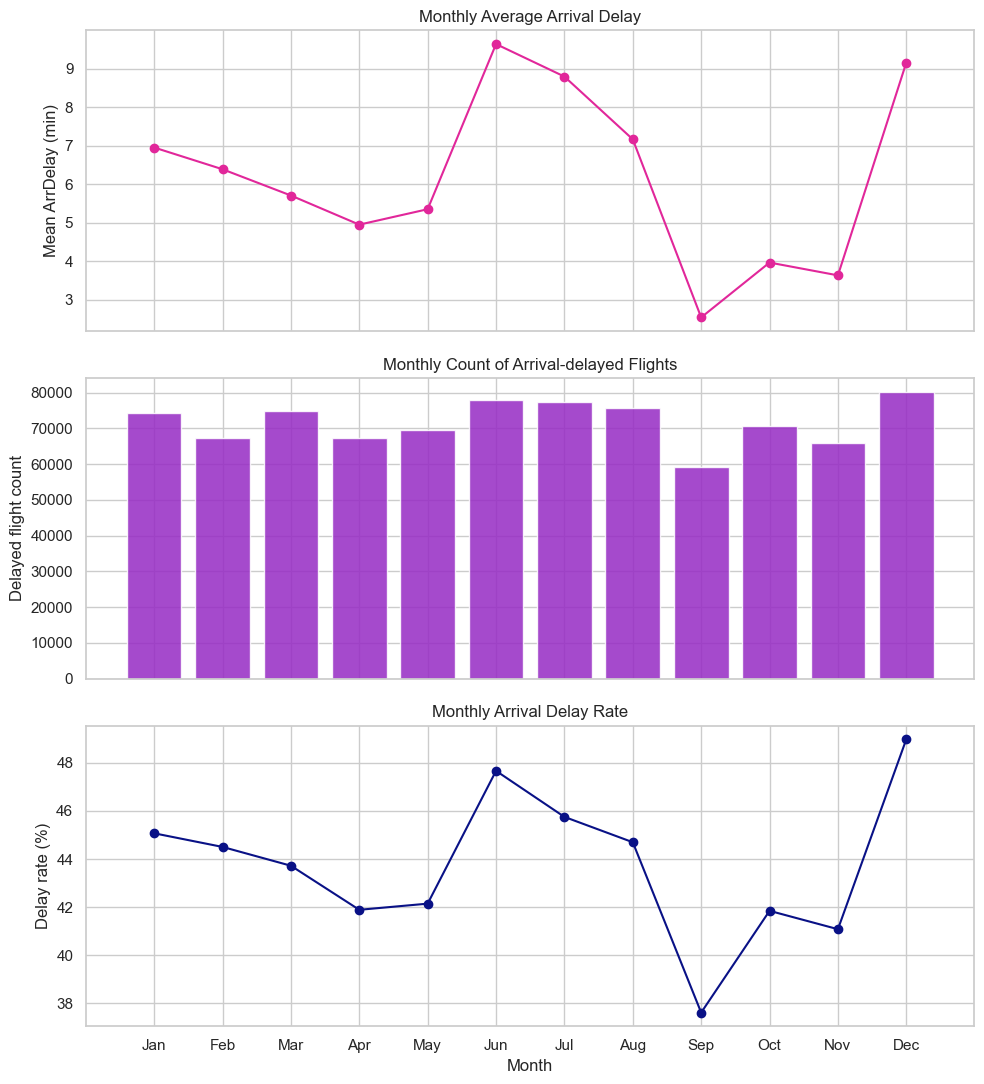

,total_flights,mean_arr_delay,delayed_flights,delay_rate
Month,,,,
1,164540,6.953,74162,0.451
2,151451,6.388,67404,0.445
3,170921,5.707,74733,0.437
4,160878,4.950,67396,0.419
5,164657,5.351,69400,0.421
6,163559,9.639,77964,0.477
7,168946,8.795,77299,0.458
8,169316,7.165,75685,0.447
9,157014,2.541,59070,0.376


In [37]:
monthly_summary = (
    oper.groupby("Month")
    .agg(
        total_flights=("ArrDelay", "size"),
        mean_arr_delay=("ArrDelay", "mean"),
        delayed_flights=("IsArrivalDelayed", "sum"),
        delay_rate=("IsArrivalDelayed", "mean"),
    )
    .reindex(range(1, 13))
)

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

axes[0].plot(monthly_summary.index, monthly_summary["mean_arr_delay"], marker="o", color="#e1279a")
axes[0].set_ylabel("Mean ArrDelay (min)")
axes[0].set_title("Monthly Average Arrival Delay")

axes[1].bar(monthly_summary.index, monthly_summary["delayed_flights"], color="#962ac4", alpha=0.85)
axes[1].set_ylabel("Delayed flight count")
axes[1].set_title("Monthly Count of Arrival-delayed Flights")

axes[2].plot(monthly_summary.index, monthly_summary["delay_rate"] * 100, marker="o", color="#091186")
axes[2].set_ylabel("Delay rate (%)")
axes[2].set_xlabel("Month")
axes[2].set_title("Monthly Arrival Delay Rate")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(months)

plt.tight_layout()
plt.show()

display(monthly_summary.round(3))

**Insight:** 

The monthly analysis shows clear seasonal variation in both the severity and frequency of arrival delays. Mid-year months (June–July) and December exhibit the highest average delays, indicating more severe disruptions during peak travel periods. This is likely driven by increased passenger demand, air traffic congestion, and operational constraints.

In contrast, September shows a noticeable decline in delays, suggesting reduced traffic pressure and improved system efficiency following the summer peak.

When considering delay counts and delay rates alongside average delay, a more complete picture emerges. Months with high delay counts do not necessarily indicate worse performance if flight volumes are also high. However, consistently elevated delay rates during peak periods confirm that a larger proportion of flights are affected, not just a higher total number.

Overall, the results demonstrate that delays are strongly influenced by seasonal demand fluctuations. Peak travel periods increase both the likelihood and severity of delays, reinforcing the impact of congestion on overall system performance.

---

### 3.2 Average Arrival Delay by Day of Week

This analysis evaluates how arrival delays vary across different days of the week. By aggregating mean delay durations by weekday, we can identify whether certain days consistently experience higher levels of disruption.

This perspective is particularly useful for understanding how operational load, business travel patterns, and scheduling intensity influence system performance throughout the week.

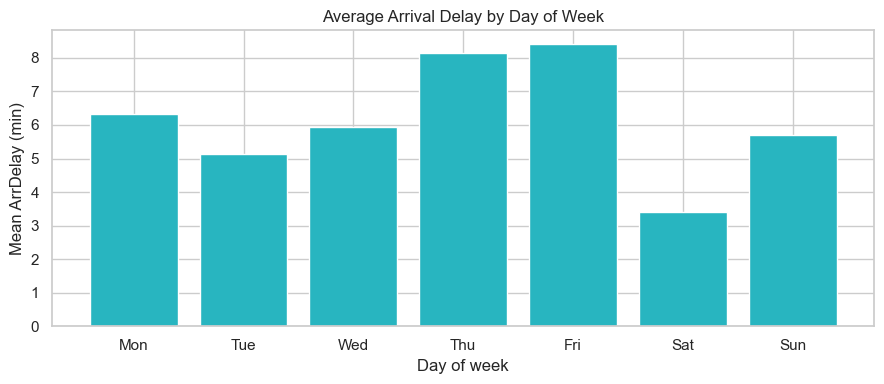

In [38]:
dow_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
by_dow = oper.groupby("DayOfWeek")["ArrDelay"].mean().reindex(range(1, 8))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 8), by_dow.values, color="#28b5c0")
ax.set_xticks(range(1, 8))
ax.set_xticklabels([dow_map[i] for i in range(1, 8)])
ax.set_xlabel("Day of week")
ax.set_ylabel("Mean ArrDelay (min)")
ax.set_title("Average Arrival Delay by Day of Week")
plt.tight_layout()
plt.show()

**Insight:** 

The results show a clear weekday effect in arrival delays:

- Thursday and Friday exhibit the highest average delays, suggesting increased congestion toward the end of the workweek.
- Saturday has the lowest delays, indicating reduced traffic volume and less operational pressure.
- Early-week days (Monday–Wednesday) show moderate delay levels, reflecting more balanced demand.

This pattern aligns with expected travel behavior, where business and leisure travel intensifies later in the week. The findings suggest that operational strain builds up over the week, leading to more frequent or severe delays by Thursday and Friday.

---

### 3.3 Average Arrival Delay by Hour of Day

This section examines how arrival delays vary throughout the day based on scheduled departure hour. Temporal patterns at the hourly level are critical for identifying congestion periods, delay propagation effects, and scheduling inefficiencies.

By analyzing delays across a 24-hour cycle, we can observe how early-day conditions influence later operations and whether delays accumulate over time.

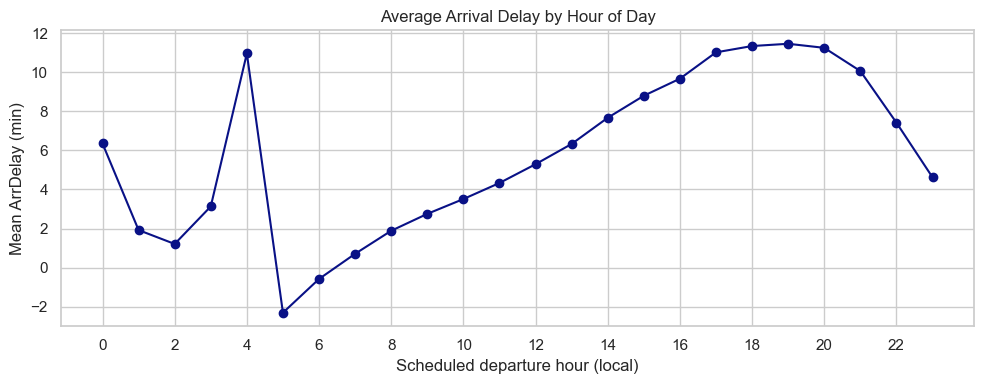

In [39]:
h = oper.dropna(subset=["DepHour"])
by_hour = h.groupby("DepHour")["ArrDelay"].mean().reindex(range(24))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_hour.index, by_hour.values, marker="o", color="#091186")
ax.set_xlabel("Scheduled departure hour (local)")
ax.set_ylabel("Mean ArrDelay (min)")
ax.set_title("Average Arrival Delay by Hour of Day")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

**Insight:** 

A strong time-of-day effect is observed:

- Early morning hours (around 5–7 AM) show the lowest delays, with some flights even arriving early (negative delay).
- Delays steadily increase throughout the day, peaking in the late afternoon and evening (5–8 PM).
- After peak hours, delays begin to decline again late at night.

This pattern provides strong evidence of delay propagation, where early disruptions accumulate and cascade throughout the day. Flights scheduled later are increasingly exposed to upstream delays, congestion, and resource limitations.

From an operational perspective, this suggests that improving early-day punctuality could have a compounding positive effect on overall system performance, reducing delays across the entire daily schedule.

---

## 4. Which Airlines and Airports are Most Affected?

Top 10 by mean arrival delay (minimum 500 flights per airline / origin to reduce noise).

#### Airline and Airport Delay Comparison

This section compares arrival delay performance across airlines and origin airports to identify where delays are most pronounced. By focusing on entities with a minimum number of flights, the analysis ensures that results are based on sufficiently large and reliable samples.

Both the average delay and the proportion of delayed flights are examined to capture differences in delay severity and frequency. This allows for a more complete understanding of whether poor performance is driven by a few extreme delays or by consistently high levels of disruption.

By comparing airlines and airports simultaneously, the analysis provides insight into whether delays are primarily influenced by carrier-level operational practices—such as scheduling efficiency and turnaround management—or by airport-level constraints, including congestion, infrastructure limitations, and air traffic control conditions.

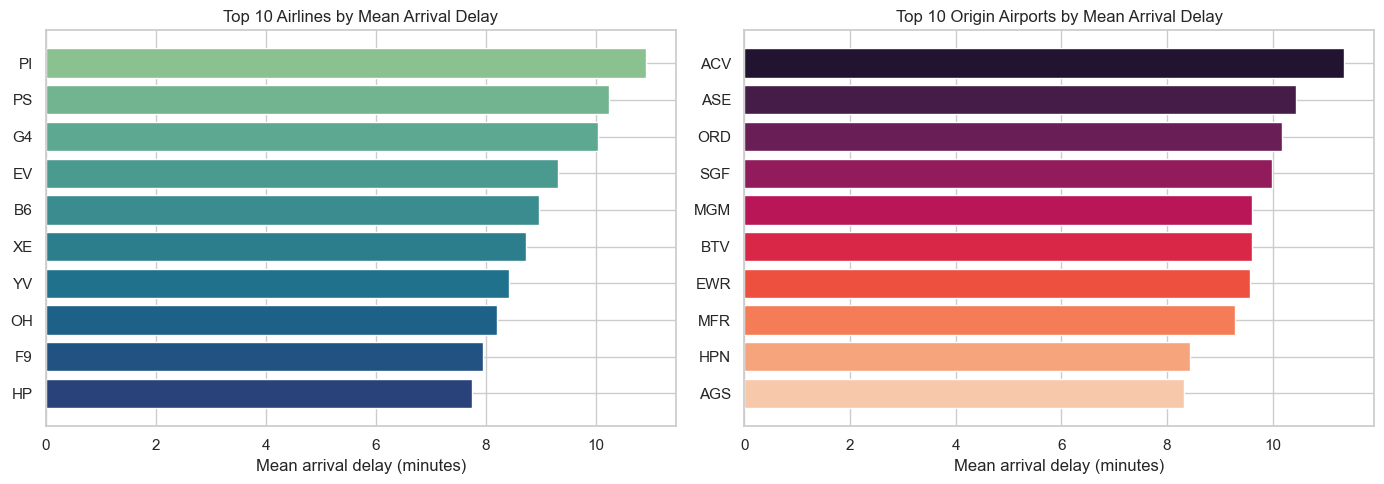

,flights,mean_arr_delay,median_arr_delay,delay_rate
Reporting_Airline,,,,
PI,8849,10.906,5.0,0.688
PS,859,10.231,3.0,0.589
G4,2260,10.032,-4.0,0.392
EV,65584,9.316,-4.0,0.406
B6,37033,8.967,-4.0,0.411
XE,34831,8.722,-2.0,0.441
YV,21861,8.410,-3.0,0.392
OH,23975,8.205,-2.0,0.427
F9,14175,7.937,-2.0,0.448


,flights,mean_arr_delay,median_arr_delay,delay_rate
Origin,,,,
ACV,524,11.350,-3.0,0.391
ASE,646,10.434,-4.0,0.382
ORD,100208,10.172,0.0,0.474
SGF,1540,9.992,-3.0,0.391
MGM,984,9.612,0.0,0.478
BTV,1673,9.605,-3.0,0.422
EWR,40510,9.575,-1.0,0.468
MFR,953,9.291,-2.0,0.410
HPN,2238,8.433,-3.0,0.411


In [40]:
def top_delay_entities(gb_col, min_n=500, top_k=10):
    g = (
        oper.groupby(gb_col)
        .agg(
            flights=("ArrDelay", "size"),
            mean_arr_delay=("ArrDelay", "mean"),
            median_arr_delay=("ArrDelay", "median"),
            delay_rate=("IsArrivalDelayed", "mean"),
        )
        .query("flights >= @min_n")
        .sort_values("mean_arr_delay", ascending=False)
        .head(top_k)
    )
    return g


top_airlines = top_delay_entities("Reporting_Airline")
top_airports = top_delay_entities("Origin")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    top_airlines.index.astype(str),
    top_airlines["mean_arr_delay"],
    color=sns.color_palette("crest", len(top_airlines)),
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean arrival delay (minutes)")
axes[0].set_title("Top 10 Airlines by Mean Arrival Delay")

axes[1].barh(
    top_airports.index.astype(str),
    top_airports["mean_arr_delay"],
    color=sns.color_palette("rocket", len(top_airports)),
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean arrival delay (minutes)")
axes[1].set_title("Top 10 Origin Airports by Mean Arrival Delay")

plt.tight_layout()
plt.show()

display(top_airlines.round(3))
display(top_airports.round(3))

**Insight:**

The airline and airport comparison reveals clear differences in delay performance across operational entities. Mean arrival delays range from approximately 7 to 11 minutes across the top groups, indicating a meaningful performance gap between better- and worse-performing airlines and airports.

Importantly, these differences are supported by delay rates, which show that higher average delays are not driven solely by a few extreme cases but reflect a broader pattern affecting a significant proportion of flights. The inclusion of median delay further highlights the skewness of delay distributions, with many entities showing negative medians despite positive means, confirming the presence of occasional large delays.

At the airline level, variation suggests differences in scheduling efficiency, turnaround management, and operational resilience. At the airport level, consistently higher delays point to external factors such as congestion, infrastructure constraints, and air traffic control limitations.

Overall, the results demonstrate that delays are influenced by both internal airline operations and external airport conditions. This indicates that improving performance requires targeted interventions at both levels rather than relying solely on system-wide policies.

---

## 5. Arrival VS Departure Delay

Random sample for readability on large \(n\).

**Relationship Between Departure and Arrival Delays**

This section investigates the relationship between departure delays and arrival delays using a scatter plot. Understanding this relationship is essential for determining whether delays originate at departure or are primarily accumulated during flight.

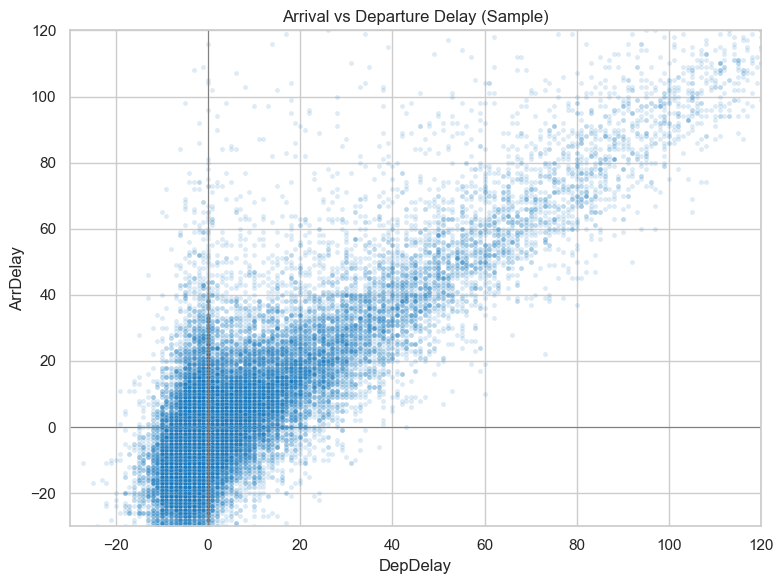

In [41]:
sample_n = min(50_000, len(oper))
sam = oper.sample(sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=sam, x="DepDelay", y="ArrDelay", alpha=0.15, s=12, color="#1679bf", ax=ax)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlim(-30, 120)
ax.set_ylim(-30, 120)
ax.set_title("Arrival vs Departure Delay (Sample)")
plt.tight_layout()
plt.show()

**Insight:** 

A strong positive linear relationship is evident between departure and arrival delays:

- Flights that depart late tend to also arrive late.
- The clustering along a diagonal trend indicates high dependency between the two variables.

However, there is some spread around the trend line, suggesting that:

- Certain flights recover time during transit
- Others experience additional delays mid-flight or during arrival

Overall, departure delay appears to be a primary driver of arrival delay, reinforcing the importance of minimizing delays at the origin stage.

---

## 6. Correlation Heatmap (Delay-Related Numerics)

Subset of columns most tied to delay minutes and causes.

**Correlation Analysis of Delay-Related Features**

This section presents a correlation matrix of key delay-related variables, including arrival delay, departure delay, and specific delay causes (e.g., carrier, weather, NAS). The objective is to quantify the strength and direction of relationships between these variables.

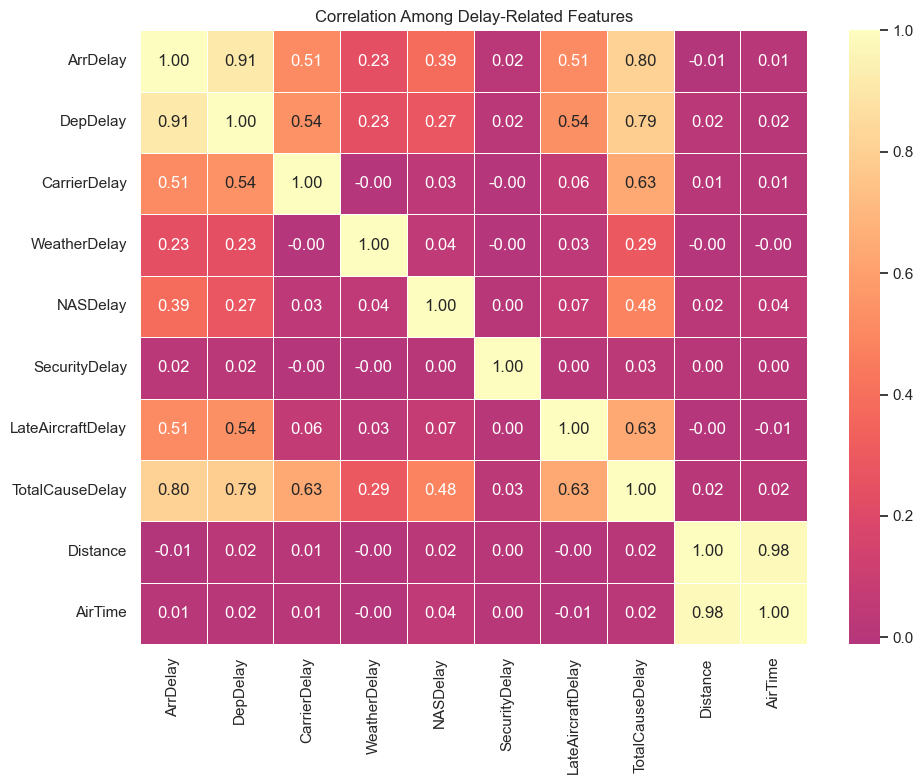

In [42]:
corr_cols = [
    c
    for c in [
        "ArrDelay",
        "DepDelay",
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay",
        "TotalCauseDelay",
        "Distance",
        "AirTime",
    ]
    if c in oper.columns
]
cm = oper[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="magma", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Among Delay-Related Features")
plt.tight_layout()
plt.show()

**Insight:** 

Key observations from the correlation matrix include:

- Arrival delay and departure delay are highly correlated (~0.91), confirming that departure delays strongly influence arrival outcomes.
- TotalCauseDelay shows strong correlation with both arrival and departure delays (~0.80), indicating that aggregated delay causes are major contributors.
- CarrierDelay and LateAircraftDelay also show moderate correlations, suggesting operational inefficiencies and aircraft turnaround issues play a role.
- Weather and Security delays exhibit weak correlations, implying they are less frequent or more isolated in impact.
- Distance and AirTime are highly correlated (~0.98) but show negligible correlation with delays, indicating that flight length itself is not a primary driver of delay.

Taken together, these relationships reinforce that arrival delays are primarily driven by operational and systemic factors, particularly those originating at departure and during aircraft turnaround. External factors such as distance play a minimal role, highlighting that improvements in operational efficiency are likely to yield the greatest reductions in delay.

---

## 7. Daily Delay Anomaly Detection

To identify unusual operating days, daily average arrival delay is standardized using a z-score. Days with the largest absolute z-scores represent dates where delay behaviour deviated most strongly from the overall daily pattern.

,FlightDate,total_flights,mean_arr_delay,delay_rate,z_mean_arr_delay
5095,2001-09-13,10,84.000,0.800,10.053
10669,2016-12-17,140,75.288,0.757,8.928
5096,2001-09-14,74,54.753,0.797,6.277
1177,1990-12-21,139,54.628,0.835,6.260
10779,2017-04-06,158,53.172,0.658,6.072
4523,2000-02-18,127,52.967,0.819,6.046
9591,2014-01-04,136,52.118,0.699,5.936
4112,1999-01-03,109,49.541,0.872,5.603
1178,1990-12-22,125,48.805,0.832,5.508
7749,2008-12-19,152,46.960,0.763,5.270


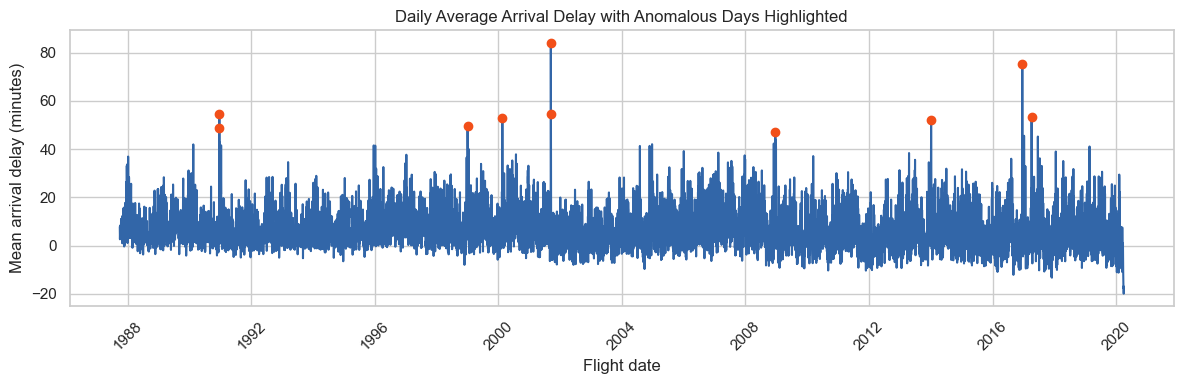

In [43]:
daily_delay = (
    oper.groupby("FlightDate")
    .agg(
        total_flights=("ArrDelay", "size"),
        mean_arr_delay=("ArrDelay", "mean"),
        delay_rate=("IsArrivalDelayed", "mean"),
    )
    .reset_index()
)

daily_delay["z_mean_arr_delay"] = (
    daily_delay["mean_arr_delay"] - daily_delay["mean_arr_delay"].mean()
) / daily_delay["mean_arr_delay"].std()

top_anomaly_days = daily_delay.reindex(
    daily_delay["z_mean_arr_delay"].abs().sort_values(ascending=False).index
).head(10)

display(top_anomaly_days.round(3))

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    daily_delay["FlightDate"],
    daily_delay["mean_arr_delay"],
    color="#3266a8",
)

ax.scatter(
    top_anomaly_days["FlightDate"],
    top_anomaly_days["mean_arr_delay"],
    color="#f24f19",
    zorder=3,
)

ax.set_xlabel("Flight date")
ax.set_ylabel("Mean arrival delay (minutes)")
ax.set_title("Daily Average Arrival Delay with Anomalous Days Highlighted")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**

The anomaly detection results identify dates where average arrival delay was unusually high or low compared with the overall daily pattern. These dates are important because they may represent severe weather events, holiday travel pressure, air traffic congestion, or other operational disruptions.

By using z-scores, the analysis provides a quantitative way to flag abnormal delay behaviour rather than relying only on visual inspection. This strengthens the exploratory analysis by highlighting specific days that may require deeper investigation in later stages of the project.

---

### Overall Insights and Key Findings

This exploratory analysis provides a comprehensive view of flight delay behaviour across temporal, operational, and system-level dimensions.

Several key insights emerge:

- Delays are widespread, with a substantial proportion of flights arriving late, indicating that delays are a systemic issue rather than isolated events.
- Temporal effects are highly significant, with both delay severity and likelihood increasing throughout the day and peaking in the evening, demonstrating clear evidence of delay propagation.
- Strong seasonal patterns are observed, as peak travel periods (mid-year and December) exhibit both higher average delays and higher delay rates, suggesting capacity constraints during periods of elevated demand.
- Operational factors are the primary drivers of delays, supported by the strong relationship between departure delays, arrival delays, and total delay causes, while structural variables such as distance show minimal influence.
- Meaningful variation exists across airlines and airports, indicating that both carrier-level practices and airport-level constraints contribute to performance differences.

Overall, the findings indicate that flight delays are driven predominantly by operational congestion and scheduling inefficiencies rather than inherent flight characteristics. This suggests that improvements in scheduling strategies, resource allocation, and delay management could significantly enhance overall system performance.